# Exploratory Data Analysis

In [27]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

import src.utils as utils

In [28]:
df = pd.read_csv("../data/bank_churn_raw.csv")

target_column_name = "Exited"
cardinality_threshold = 100 # for categorical classes in order not to plot 10000

df_numeric = df.select_dtypes(include=["number"])
df_category = df.select_dtypes(include=["object", "category"])

categorical_cols = [col for col in df_category.columns if df[col].nunique() < cardinality_threshold]

numerical_cols = [col for col in df_numeric.columns if col != target_column_name]

## Understanding raw data

In [29]:
df.shape

(10000, 13)

In [30]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [31]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df.dtypes

CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [33]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Missing values

In [34]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Target variable

In [35]:
df_target = df[target_column_name]

In [36]:
df_target.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

## Univariate analysis

### Numerical columns

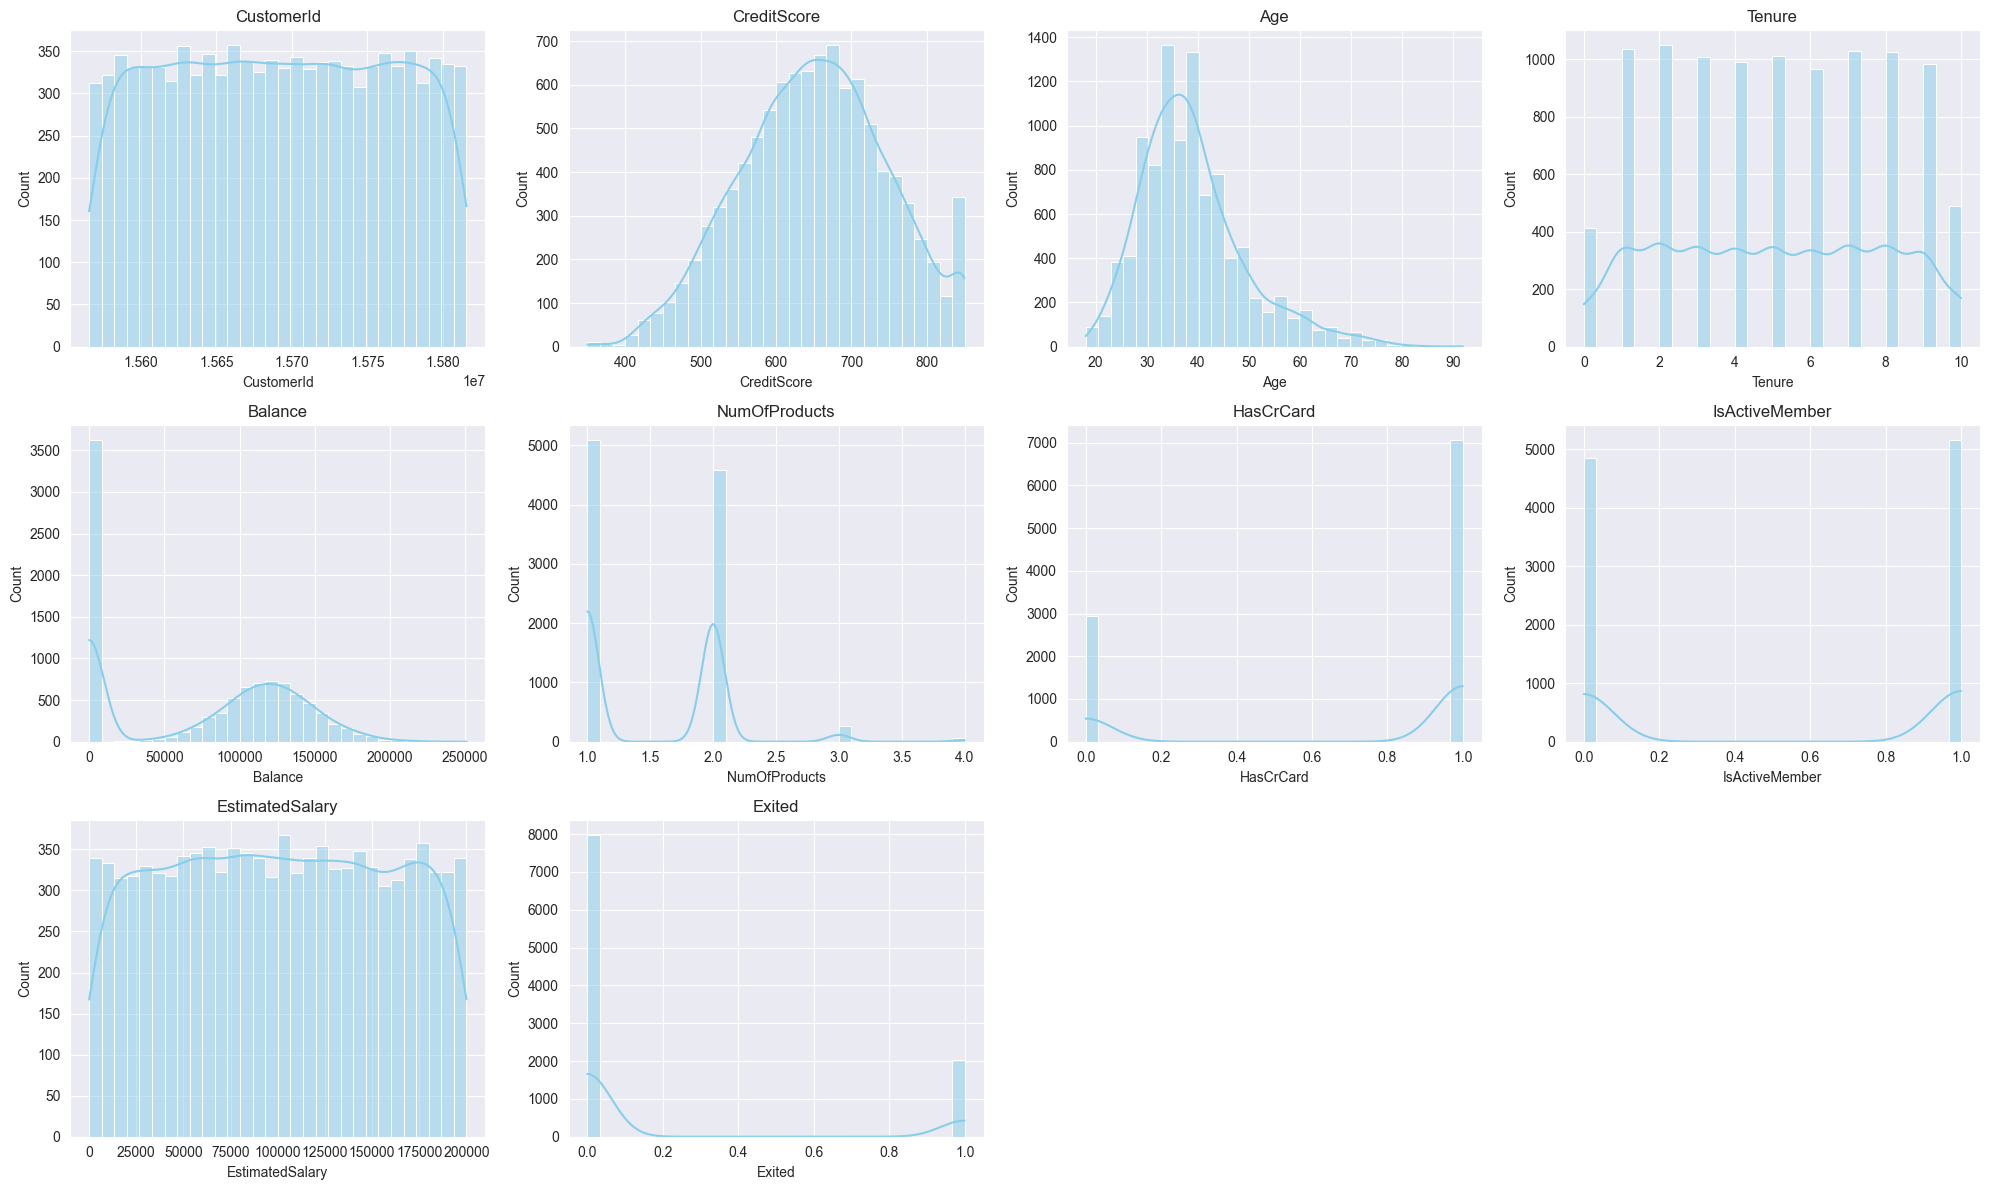

In [37]:
utils.plot_grid(
    df_numeric.columns,
    lambda col, ax: (
        sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax, color="skyblue"),
        ax.set_title(col)
    )
)

### Categorical columns

In [38]:
for column in df_category.columns:
    if(df[column].nunique() > 10):
        print(column)
        print("nunique:", df[column].nunique())
    else:
        print(df[column].value_counts())
    print("#######################")

Surname
nunique: 2932
#######################
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
#######################
Gender
Male      5457
Female    4543
Name: count, dtype: int64
#######################


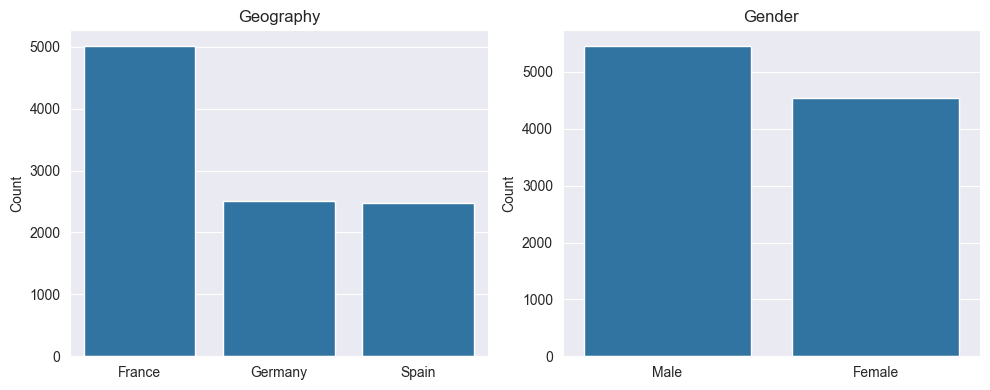

In [39]:
utils.plot_grid(
    categorical_cols,
    lambda col, ax: (
        sns.barplot(
            x=df[col].value_counts().index,
            y=df[col].value_counts().values,
            ax=ax
        ),
        ax.set_title(col),
        ax.set_ylabel("Count"),
        ax.set_xlabel("")
    )
)

## Bivariate analysis

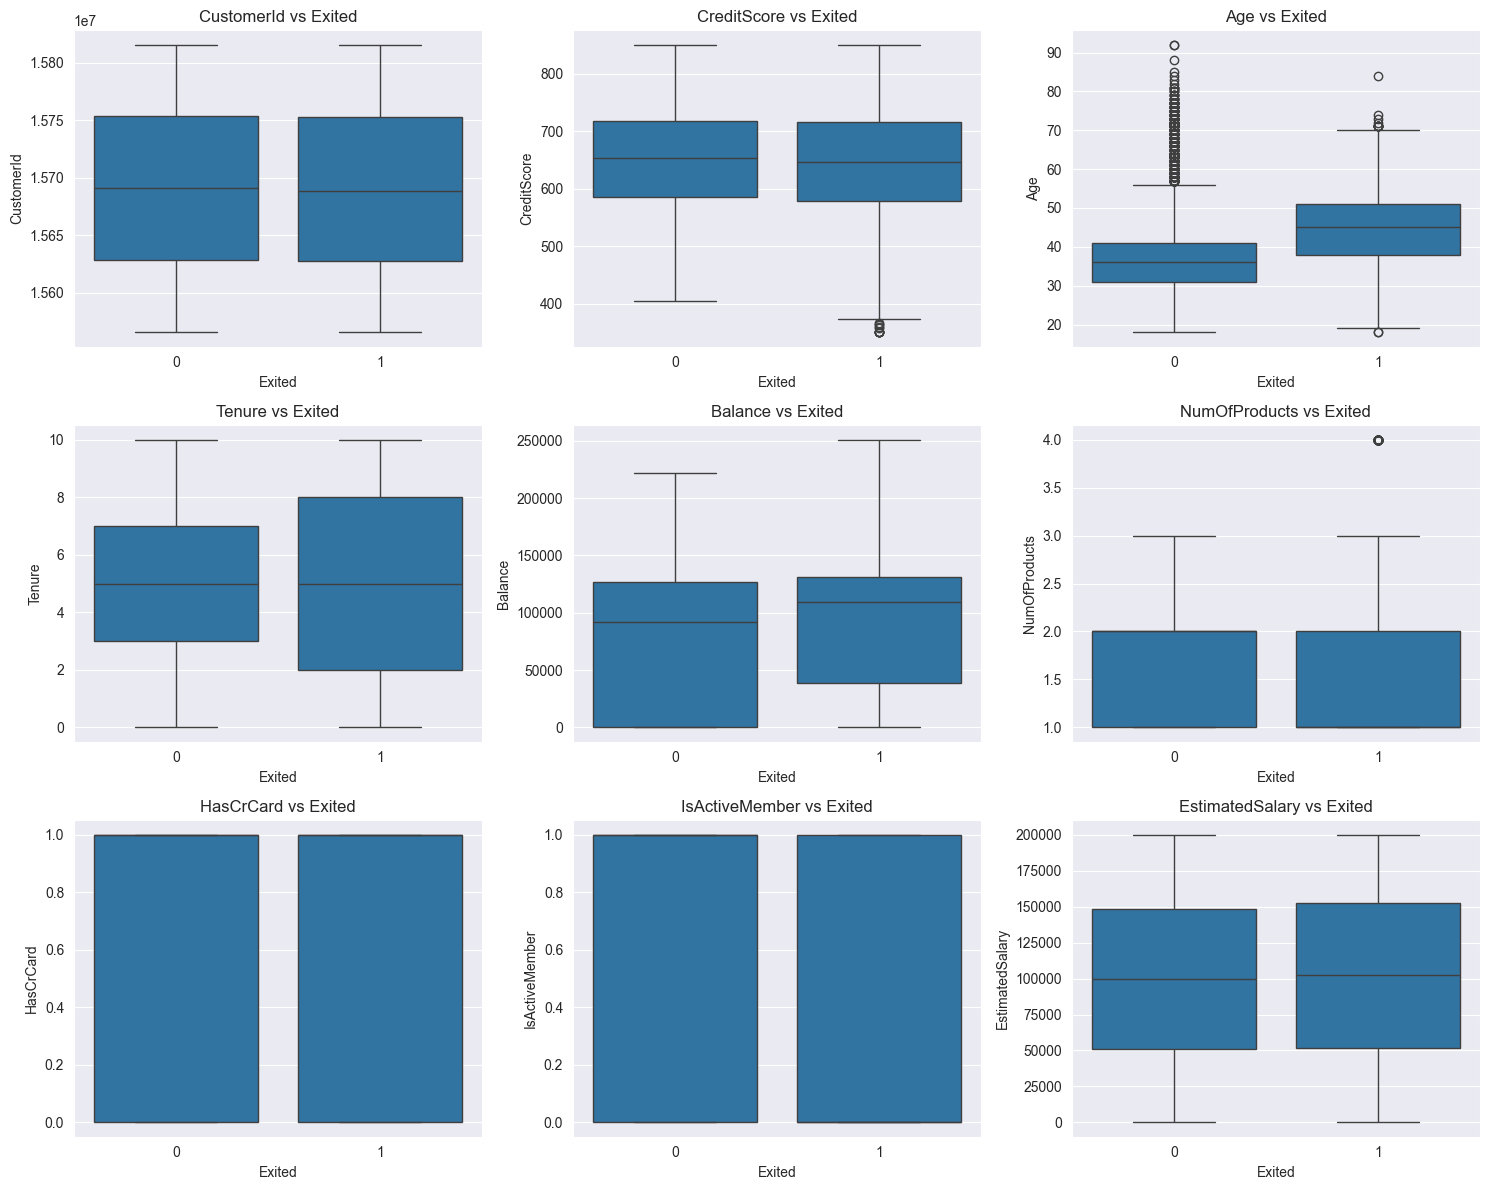

In [40]:
num_cols = df_numeric.columns
num_cols = [col for col in num_cols if col != target_column_name]

utils.plot_grid(
    num_cols,
    lambda col, ax: (
        sns.boxplot(x=df[target_column_name], y=df[col], ax=ax),
        ax.set_title(f"{col} vs {target_column_name}")
    )
)

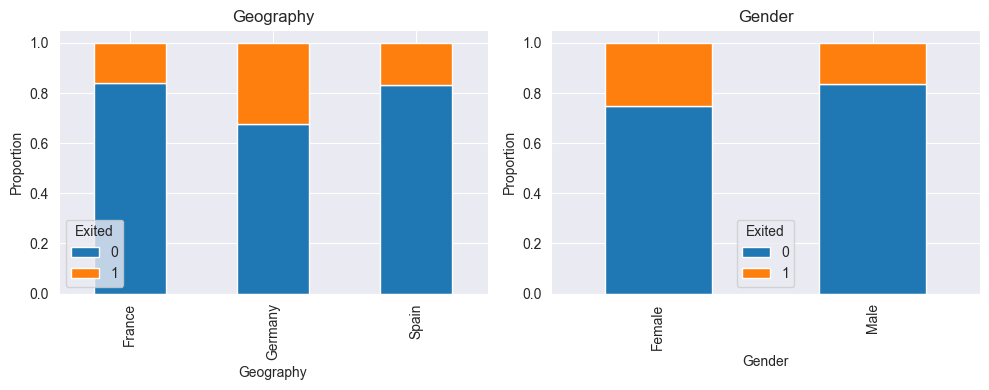

In [41]:
utils.plot_grid(
    categorical_cols,
    lambda col, ax: (
        pd.crosstab(df[col], df[target_column_name], normalize="index")
        .plot(kind="bar", stacked=True, ax=ax),
        ax.set_title(col),
        ax.set_ylabel("Proportion")
    )
)

## Corelation

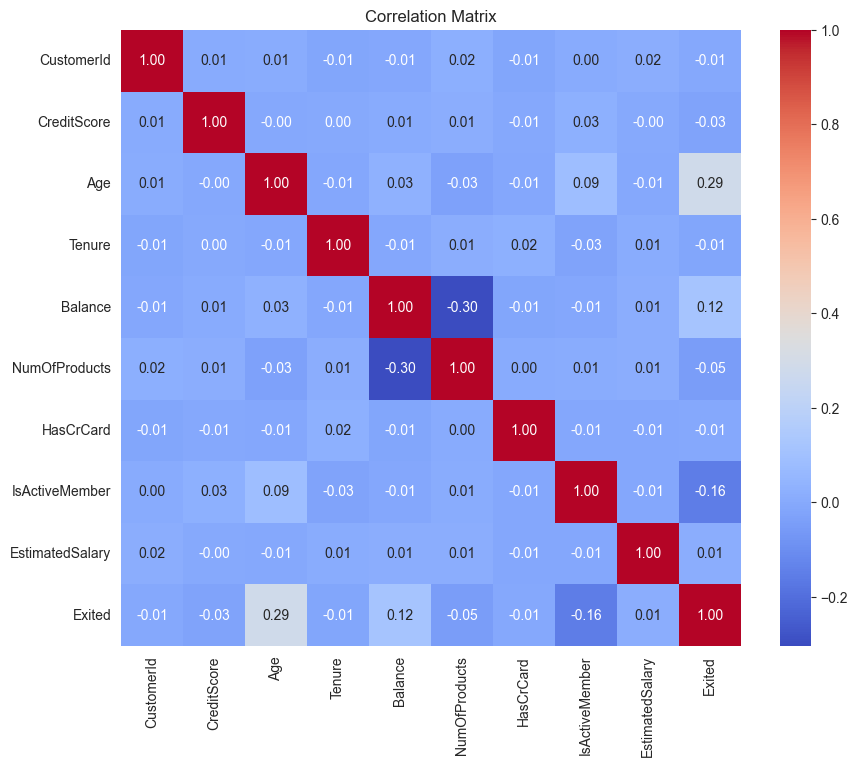

In [42]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Outliers

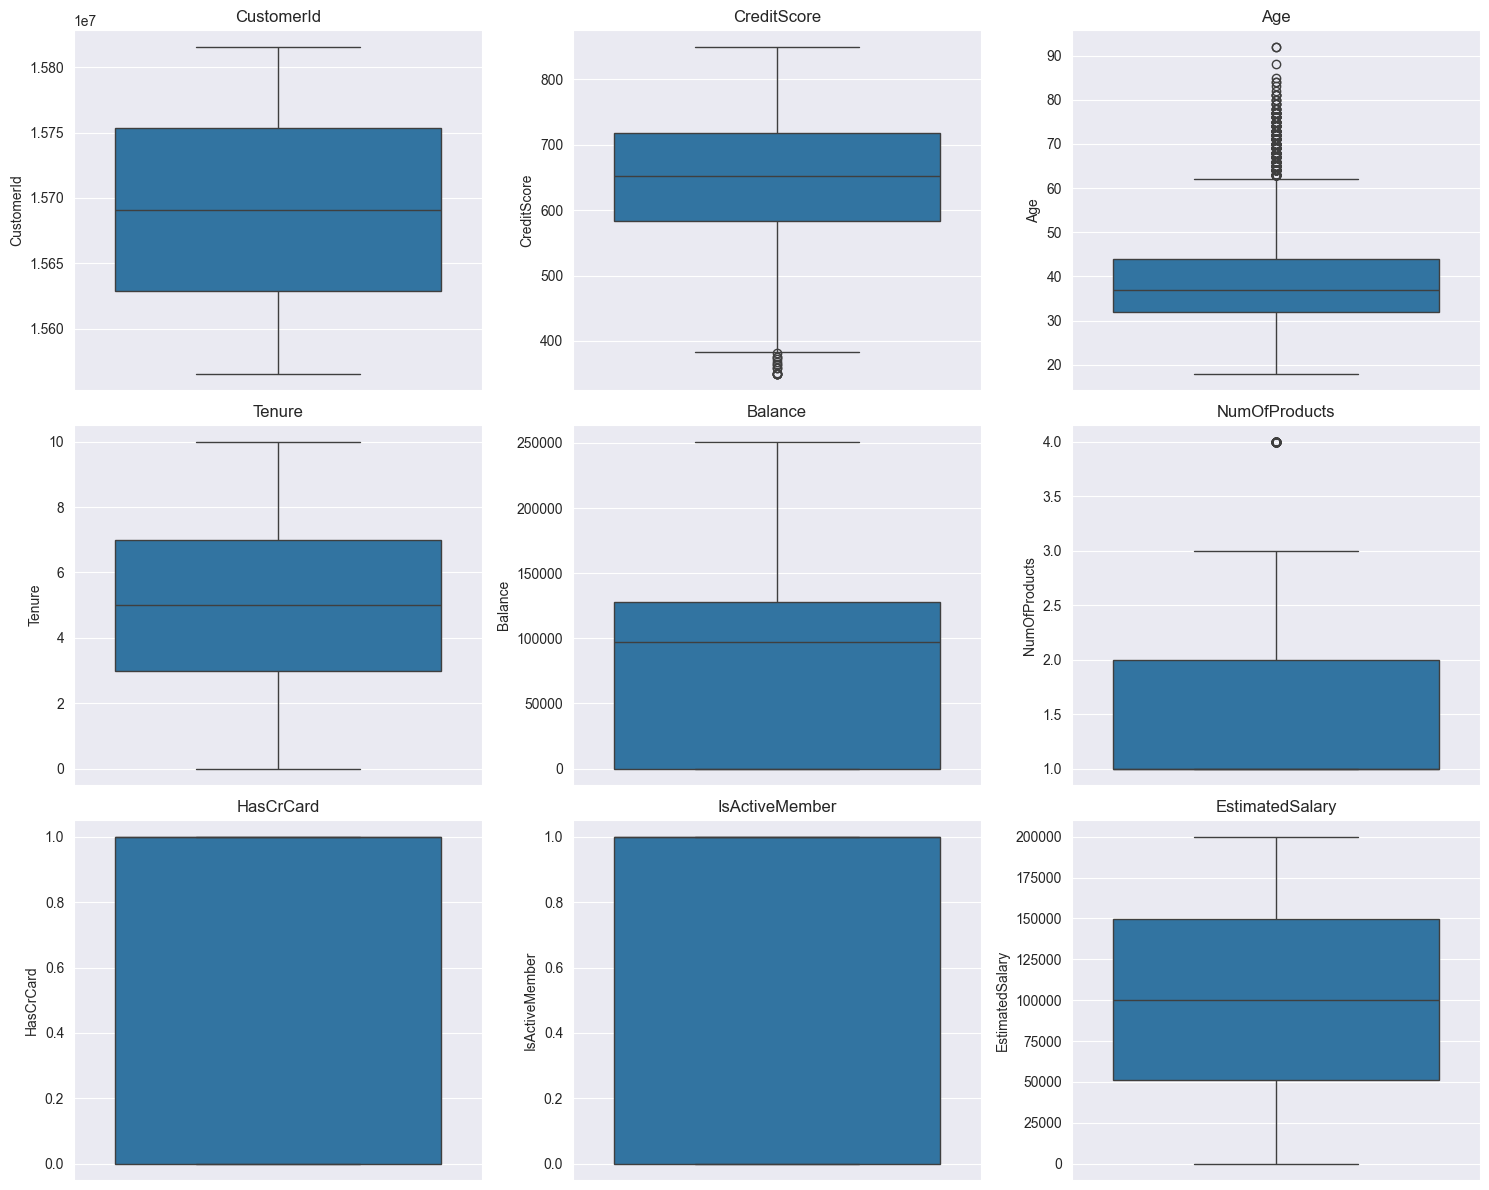

In [43]:
utils.plot_grid(
    numerical_cols,
    lambda col, ax: (
        sns.boxplot(y=df[col], ax=ax),
        ax.set_title(col)
    )
)

## Data integrity

In [44]:
df.duplicated().sum()

0

In [45]:
df[df.duplicated()]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
